# ⚠️ Archive : `ml_0` avant la boucle automatique (04/10/2026)

Version du socle `ml_0` exécutée le 04/10/2026, **avant l'automatisation** : GridSearch sur les grilles de la première itération, puis grilles ajustées à la main pour juguler le surapprentissage. Score de décision de l'époque : moyenne du F2 au seuil de 0,5 et du ROC AUC.

C'est sur ces résultats qu'a été fixé le rappel cible de départ : au seuil de 0,5, les meilleurs modèles trouvaient déjà environ 60 % des défauts en validation, sans être réglés pour ça (cellule de détection, plus bas). La méthode actuelle est décrite dans `methodologie_ML.md`.

**À ne pas réexécuter** : les sorties ci-dessous sont celles du 04/10/2026, la trace de la méthode v0 ; une relance les remplacerait. Si le notebook est relancé malgré tout, `numero_scenario = "0_etalon"` fait enregistrer le modèle dans `best_models/model_ml_0_etalon.joblib`, sans écraser celui de `ml_0`.


# ml_0 : le socle du machine learning

**But** : mesurer, sur les clients laissés au machine learning, ce que les **6 modèles d'origine** obtiennent avec les **23 variables d'origine** du dataset, sans aucune colonne créée. C'est le point zéro : chaque scénario suivant (`ml_1`, `ml_2`…) ajoute des colonnes et se compare à ce socle.

**Données** : `data/ML/train_dataset.csv`, produit par `creation_datasets_ML.ipynb` (périmètre S12, clients au contentieux à M retirés, 80 % des clients restants). **Le jeu de test n'est pas lu** : il est réservé à l'évaluation finale, une seule fois, une fois le modèle figé.

**Méthode** (identique pour tous les scénarios) :
- validation croisée stratifiée à 5 plis, `random_state=42`, sur le train uniquement ;
- **score de décision** = moyenne du F2 et du ROC AUC, mesurés en validation ; il est donné avec son **écart-type sur les 5 plis** : un écart entre deux modèles plus petit que cet écart-type n'est pas une différence, c'est du bruit ;
- seuil de décision à 0,5 (valeur par défaut des modèles) : le F2, les défauts détectés et la précision en dépendent ; le seuil sera réglé sur le modèle final ;
- défauts détectés et précision mesurés en validation (chaque client est prédit par un modèle qui ne l'a pas vu).

**Étapes** :
1. chargement du train et choix des variables ;
2. premier essai des 6 modèles, avec leurs réglages par défaut ;
3. recherche des hyperparamètres (GridSearch), optimisée sur le score de décision, avec alertes de surapprentissage et paramètres au bord de leur grille ;
3 bis. ajustement à la main des hyperparamètres des modèles en alerte ;
4. matrices de confusion, défauts détectés, précision et importance des variables, en validation ;
5. podium détaillé et enregistrement du meilleur modèle.

In [ ]:
numero_scenario = "0_etalon"

## 1. Chargement et variables

Les 23 variables d'origine : le plafond (`LIMIT_BAL`), la démographie (`SEX`, `EDUCATION`, `MARRIAGE`, `AGE`), les codifications de paiement (`PAY_1` à `PAY_6`, corrigées au niveau 5 du nettoyage), les factures (`BILL_AMT1` à `BILL_AMT6`) et les paiements (`PAY_AMT1` à `PAY_AMT6`). L'identifiant `ID` et la cible `dpnm` ne sont pas des variables.

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

# Racine du projet : premier dossier parent qui contient 'data'
current_dir = Path.cwd()
root_dir = next(p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists())

train = pd.read_csv(root_dir / "data" / "ML" / "train_dataset.csv")

# Variables d'origine, par type d'encodage
num_col = ["LIMIT_BAL", "AGE"] + [f"BILL_AMT{n}" for n in range(1, 7)] + [f"PAY_AMT{n}" for n in range(1, 7)]
cat_col = ["SEX", "EDUCATION", "MARRIAGE"]          # catégories sans ordre : one-hot
ord_col = [f"PAY_{n}" for n in range(1, 7)]         # codifications ordonnées : encodage ordinal
variables = num_col + cat_col + ord_col

X_train = train[variables].reset_index(drop=True)
y_train = train["dpnm"].reset_index(drop=True)

print(f"Clients du train : {len(train)}")
print(f"Variables        : {len(variables)}")
print(f"Défauts          : {y_train.sum()} ({y_train.mean() * 100:.2f} %)")

Clients du train : 19358
Variables        : 23
Défauts          : 3084 (15.93 %)


**Encodage** (dans le pipeline, donc appris sur chaque pli de la validation croisée, sans fuite) :
- montants, plafond et âge : centrés et réduits (`StandardScaler`) ;
- `SEX`, `EDUCATION`, `MARRIAGE` : une colonne par catégorie (`OneHotEncoder`) ;
- `PAY_1` à `PAY_6` : encodage ordinal, qui garde l'ordre des codifications.

Le déséquilibre des classes (environ 1 client sur 6 en défaut) est compensé par une pondération des défauts pour les modèles qui l'acceptent (`class_weight='balanced'`, `scale_pos_weight` pour CatBoost). KNN et le réseau de neurones (MLP) n'ont pas cette option : ils sont gardés tels quels, comme dans la première itération.

In [10]:
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# Pondération des défauts pour CatBoost (part des non-défauts / part des défauts)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_col),
    ("nom", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_col),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ord_col),
])

def score_decision(estimator, X, y):
    # Score de décision : moyenne du F2 (au seuil de 0,5) et du ROC AUC
    proba = estimator.predict_proba(X)[:, 1]
    pred = estimator.predict(X)
    return (fbeta_score(y, pred, beta=2) + roc_auc_score(y, proba)) / 2

scorers = {
    "decision": score_decision,
    "f2": make_scorer(fbeta_score, beta=2),
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def modeles_de_base():
    # Les 6 modèles d'origine, avec leurs réglages de la première itération
    return {
        "LogisticRegression": make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
        "SVM": make_pipeline(preprocessor, CalibratedClassifierCV(estimator=SVC(class_weight="balanced", random_state=42), ensemble=False)),
        "MLPClassifier": make_pipeline(preprocessor, MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42, early_stopping=True)),
        "KNN": make_pipeline(preprocessor, KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
        "RandomForest": make_pipeline(preprocessor, RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
        "CatBoost": make_pipeline(preprocessor, CatBoostClassifier(scale_pos_weight=scale_pos, random_state=42, verbose=0, thread_count=-1, allow_writing_files=False)),
    }

In [11]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

SEUIL_SURAPPRENTISSAGE = 0.05   # écart train - val du score de décision au-delà duquel on alerte
METRIQUES = {"decision": "Score de décision", "f2": "F2", "roc_auc": "ROC AUC", "recall": "Rappel", "precision": "Précision"}

def alerte(ecart):
    if ecart > 2 * SEUIL_SURAPPRENTISSAGE:
        return "⚠️⚠️ SURAPPRENTISSAGE FORT"
    if ecart > SEUIL_SURAPPRENTISSAGE:
        return "⚠️ SURAPPRENTISSAGE"
    return "✅ OK"

def ligne_scores(nom, moy_val, std_val, moy_train):
    # Une ligne de tableau : chaque métrique en entraînement et en validation, l'écart-type du score de décision et l'alerte
    ligne = {"Modèle": nom}
    for cle, libelle in METRIQUES.items():
        ligne[f"{libelle} (train)"] = moy_train[cle]
        ligne[f"{libelle} (val)"] = moy_val[cle]
    ligne["Écart-type décision (val)"] = std_val
    ligne["Écart train - val"] = moy_train["decision"] - moy_val["decision"]
    ligne["Alerte"] = alerte(ligne["Écart train - val"])
    return ligne

def afficher_scores(lignes, titre):
    df_scores = pd.DataFrame(lignes).sort_values("Score de décision (val)", ascending=False).reset_index(drop=True)
    print(f"=== {titre} ===")
    print(df_scores.drop(columns=[c for c in df_scores.columns if c.startswith("Meilleurs") or c.startswith("Bord")]).round(4).to_string(index=False))
    for _, l in df_scores[df_scores["Écart train - val"] > SEUIL_SURAPPRENTISSAGE].iterrows():
        print(f"{l['Alerte']} : {l['Modèle']}, écart train - val de {l['Écart train - val']:.4f}")
    return df_scores

## 2. Premier essai des 6 modèles (réglages par défaut)

Chaque modèle est entraîné et évalué sur les 5 plis, avec ses réglages par défaut. Le tableau donne chaque métrique en **entraînement** et en **validation**, l'écart-type du score de décision sur les plis, l'écart entre entraînement et validation et une alerte de surapprentissage.

In [12]:
from sklearn.model_selection import cross_validate

lignes = []
for nom, modele in modeles_de_base().items():
    res = cross_validate(modele, X_train, y_train, cv=cv, scoring=scorers, return_train_score=True, n_jobs=-1, error_score="raise")
    moy_val = {k: res[f"test_{k}"].mean() for k in METRIQUES}
    moy_train = {k: res[f"train_{k}"].mean() for k in METRIQUES}
    lignes.append(ligne_scores(nom, moy_val, res["test_decision"].std(), moy_train))

df_essai = afficher_scores(lignes, "PREMIER ESSAI, RÉGLAGES PAR DÉFAUT")

=== PREMIER ESSAI, RÉGLAGES PAR DÉFAUT ===
            Modèle  Score de décision (train)  Score de décision (val)  F2 (train)  F2 (val)  ROC AUC (train)  ROC AUC (val)  Rappel (train)  Rappel (val)  Précision (train)  Précision (val)  Écart-type décision (val)  Écart train - val                     Alerte
          CatBoost                     0.8361                   0.5748      0.7517    0.4494           0.9206         0.7002          0.8754        0.5149             0.4804           0.2982                     0.0121             0.2614 ⚠️⚠️ SURAPPRENTISSAGE FORT
LogisticRegression                     0.5545                   0.5491      0.4561    0.4512           0.6529         0.6470          0.6229        0.6164             0.2203           0.2179                     0.0074             0.0054                       ✅ OK
      RandomForest                     0.9997                   0.4778      0.9993    0.2624           1.0000         0.6932          1.0000        0.2432           

**Lecture** : une ligne par modèle, triées par score de décision en validation. Seule la validation compte pour comparer les modèles ; l'entraînement sert à mesurer le surapprentissage.
- **Écart-type** : variation d'un pli à l'autre ; deux modèles dont les scores diffèrent de moins que cet écart-type sont à égalité.
- **Écart train - val** : au-delà de 0,05, le modèle apprend par cœur les clients d'entraînement sans mieux prédire les autres (⚠️) ; au-delà de 0,10, le surapprentissage est fort (⚠️⚠️).

## 3. Recherche des hyperparamètres (GridSearch)

Mêmes grilles que dans la première itération, pour les 6 modèles. La recherche choisit, pour chaque modèle, la combinaison qui donne le **meilleur score de décision en validation**.
Deux signaux sont affichés pour préparer l'ajustement à la main (étape 3 bis) : l'**alerte de surapprentissage**, et les **paramètres au bord de leur grille** (le meilleur réglage est la plus petite ou la plus grande valeur testée : le vrai optimum est peut-être au-delà).

In [13]:
from sklearn.model_selection import GridSearchCV

grilles = {
    "LogisticRegression": {"logisticregression__C": [0.01, 0.1, 1.0, 10.0]},
    "SVM": {"calibratedclassifiercv__estimator__C": [1, 2, 3], "calibratedclassifiercv__estimator__gamma": ["scale", "auto"]},
    "MLPClassifier": {"mlpclassifier__hidden_layer_sizes": [(32, 16), (64, 32), (32,)], "mlpclassifier__alpha": [0.01, 0.1, 1.0]},
    "KNN": {"kneighborsclassifier__n_neighbors": [15, 25, 37, 51], "kneighborsclassifier__weights": ["uniform", "distance"]},
    "RandomForest": {"randomforestclassifier__max_depth": [6, 8, 10], "randomforestclassifier__min_samples_leaf": [20, 50, 100], "randomforestclassifier__n_estimators": [200, 300]},
    "CatBoost": {"catboostclassifier__depth": [4, 6], "catboostclassifier__l2_leaf_reg": [5, 10, 15], "catboostclassifier__learning_rate": [0.03, 0.05]},
}

def nom_court(parametre):
    return parametre.split("__")[-1]

def bords_de_grille(grille, meilleurs):
    # Paramètres numériques dont la meilleure valeur est la plus petite ou la plus grande de la grille
    bords = []
    for p, valeurs in grille.items():
        nombres = [v for v in valeurs if isinstance(v, (int, float))]
        if len(nombres) == len(valeurs) and len(valeurs) > 1:
            if meilleurs[p] == min(valeurs):
                bords.append(f"{nom_court(p)} = {meilleurs[p]} (minimum)")
            elif meilleurs[p] == max(valeurs):
                bords.append(f"{nom_court(p)} = {meilleurs[p]} (maximum)")
    return bords

def lancer_grille(nom, modele, grille):
    grid = GridSearchCV(modele, grille, cv=cv, scoring=scorers, refit="decision", return_train_score=True, n_jobs=-1)
    grid.fit(X_train, y_train)
    r, i = grid.cv_results_, grid.best_index_
    ligne = ligne_scores(nom,
                         {k: r[f"mean_test_{k}"][i] for k in METRIQUES},
                         r["std_test_decision"][i],
                         {k: r[f"mean_train_{k}"][i] for k in METRIQUES})
    ligne["Meilleurs paramètres"] = {nom_court(k): v for k, v in grid.best_params_.items()}
    ligne["Bord de grille"] = bords_de_grille(grille, grid.best_params_)
    return grid.best_estimator_, ligne

best_models, lignes = {}, []
for nom, modele in modeles_de_base().items():
    best_models[nom], ligne = lancer_grille(nom, modele, grilles[nom])
    lignes.append(ligne)

df_grid = afficher_scores(lignes, "APRÈS GRIDSEARCH")

print("\n=== MEILLEURS PARAMÈTRES ET BORDS DE GRILLE ===")
for _, l in df_grid.iterrows():
    print(f"\n[{l['Modèle']}] {l['Meilleurs paramètres']}")
    for b in l["Bord de grille"]:
        print(f"  ⚠️ au bord de la grille : {b}")

=== APRÈS GRIDSEARCH ===
            Modèle  Score de décision (train)  Score de décision (val)  F2 (train)  F2 (val)  ROC AUC (train)  ROC AUC (val)  Rappel (train)  Rappel (val)  Précision (train)  Précision (val)  Écart-type décision (val)  Écart train - val                     Alerte
          CatBoost                     0.7012                   0.5954      0.5918    0.4802           0.8106         0.7106          0.7206        0.5830             0.3451           0.2819                     0.0127             0.1058 ⚠️⚠️ SURAPPRENTISSAGE FORT
      RandomForest                     0.6451                   0.5938      0.5347    0.4776           0.7554         0.7101          0.6595        0.5892             0.3046           0.2721                     0.0139             0.0513        ⚠️ SURAPPRENTISSAGE
LogisticRegression                     0.5546                   0.5492      0.4563    0.4515           0.6529         0.6470          0.6231        0.6167             0.2204          

**Lecture** : même tableau qu'à l'étape 2, pour la meilleure combinaison de chaque modèle. Sous le tableau, les meilleurs paramètres de chaque modèle, et ceux qui sont au bord de leur grille.

## 3 bis. Ajustement à la main des hyperparamètres

Pour les modèles en alerte (surapprentissage ou paramètre au bord de sa grille), une seconde grille est écrite à la main dans la cellule suivante, en lisant l'étape 3 :
- **surapprentissage** : on pousse vers des modèles plus simples (arbres moins profonds, feuilles plus grosses, régularisation plus forte) ;
- **paramètre au bord** : on prolonge la grille de ce côté.

**Règle pour garder la version ajustée** : elle remplace la version de l'étape 3 si son score de décision en validation est meilleur, ou s'il est à égalité (écart plus petit que l'écart-type de l'étape 3) avec un surapprentissage plus faible. À score égal, on préfère le modèle qui apprend le moins par cœur. Les grilles se règlent sur la validation, jamais sur le test.

In [14]:
# Grilles ajustées à la main, à partir des alertes de l'étape 3 (à modifier selon les résultats)
grilles_ajustees = {
    # Surapprentissage et depth au minimum, l2_leaf_reg au maximum : arbres moins profonds, régularisation plus forte
    "CatBoost": {"catboostclassifier__depth": [3, 4], "catboostclassifier__l2_leaf_reg": [15, 20, 25, 30], "catboostclassifier__learning_rate": [0.02, 0.03, 0.05]},
    # max_depth et min_samples_leaf au maximum : grille prolongée vers des feuilles plus grosses
    "RandomForest": {"randomforestclassifier__max_depth": [8, 10, 12], "randomforestclassifier__min_samples_leaf": [100, 150, 200], "randomforestclassifier__n_estimators": [300]},
    # C au maximum : grille prolongée
    "LogisticRegression": {"logisticregression__C": [10.0, 30.0, 100.0]},
}

base = modeles_de_base()
avant = df_grid.set_index("Modèle")
lignes_ajust, decisions = [], []
for nom, grille in grilles_ajustees.items():
    modele_ajuste, ligne = lancer_grille(f"{nom} (ajusté)", base[nom], grille)
    lignes_ajust.append(ligne)
    a = avant.loc[nom]
    meilleur = ligne["Score de décision (val)"] > a["Score de décision (val)"] + a["Écart-type décision (val)"]
    egal_moins_appris = (abs(ligne["Score de décision (val)"] - a["Score de décision (val)"]) <= a["Écart-type décision (val)"]
                         and ligne["Écart train - val"] < a["Écart train - val"])
    garde = meilleur or egal_moins_appris
    if garde:
        best_models[nom] = modele_ajuste
    decisions.append({
        "Modèle": nom,
        "Décision (val) avant": a["Score de décision (val)"], "Décision (val) ajusté": ligne["Score de décision (val)"],
        "Écart train - val avant": a["Écart train - val"], "Écart train - val ajusté": ligne["Écart train - val"],
        "Paramètres ajustés": ligne["Meilleurs paramètres"],
        "Version gardée": "ajustée" if garde else "étape 3",
    })

df_ajust = afficher_scores(lignes_ajust, "GRILLES AJUSTÉES À LA MAIN")
print("\n=== VERSION GARDÉE POUR CHAQUE MODÈLE AJUSTÉ ===")
print(pd.DataFrame(decisions).round(4).to_string(index=False))
for _, l in df_ajust.iterrows():
    for b in l["Bord de grille"]:
        print(f"⚠️ {l['Modèle']} encore au bord de la grille : {b}")

# Tableau des scores à jour : version gardée de chaque modèle
gardes = {d["Modèle"] for d in decisions if d["Version gardée"] == "ajustée"}
lignes_finales = [l for l in df_grid.to_dict("records") if l["Modèle"] not in gardes]
lignes_finales += [dict(l, **{"Modèle": l["Modèle"].replace(" (ajusté)", "")}) for l in df_ajust.to_dict("records") if l["Modèle"].replace(" (ajusté)", "") in gardes]
df_final = pd.DataFrame(lignes_finales).sort_values("Score de décision (val)", ascending=False).reset_index(drop=True)

=== GRILLES AJUSTÉES À LA MAIN ===
                     Modèle  Score de décision (train)  Score de décision (val)  F2 (train)  F2 (val)  ROC AUC (train)  ROC AUC (val)  Rappel (train)  Rappel (val)  Précision (train)  Précision (val)  Écart-type décision (val)  Écart train - val              Alerte
          CatBoost (ajusté)                     0.6660                   0.5981      0.5523    0.4828           0.7797         0.7135          0.6767        0.5908             0.3183           0.2791                     0.0130             0.0679 ⚠️ SURAPPRENTISSAGE
      RandomForest (ajusté)                     0.6324                   0.5949      0.5214    0.4813           0.7434         0.7085          0.6488        0.5999             0.2922           0.2691                     0.0136             0.0374                ✅ OK
LogisticRegression (ajusté)                     0.5546                   0.5492      0.4563    0.4515           0.6529         0.6470          0.6231        0.6167    

**Lecture** : le premier tableau donne les scores des versions ajustées ; le second compare, pour chaque modèle ajusté, le score de décision et le surapprentissage avant et après, et indique la version gardée selon la règle ci-dessus. Si un paramètre est encore au bord de sa grille, la grille ajustée peut être prolongée à nouveau.

## 4. Matrices de confusion, défauts détectés et importance des variables, en validation

Pour chaque modèle retenu, chaque client du train est prédit par un modèle entraîné sur les 4 autres plis, donc sans l'avoir vu (`cross_val_predict`), au seuil de 0,5.
- **Matrices de confusion** : en ligne, la réalité (solvable, défaut) ; en colonne, la prédiction. Chaque case donne l'effectif et la part de la ligne : la case en bas à droite est la part des défauts détectés (rappel).
- **Tableau** : prédits en défaut, défauts détectés, fausses alertes, défauts manqués, précision (part des clients signalés réellement en défaut) et rappel.
- **Importance des variables** : poids de chaque variable dans le modèle entraîné sur tout le train, en pourcentage (importance des arbres, coefficients de la régression logistique, poids de la première couche du réseau de neurones ; SVM et KNN n'en ont pas).

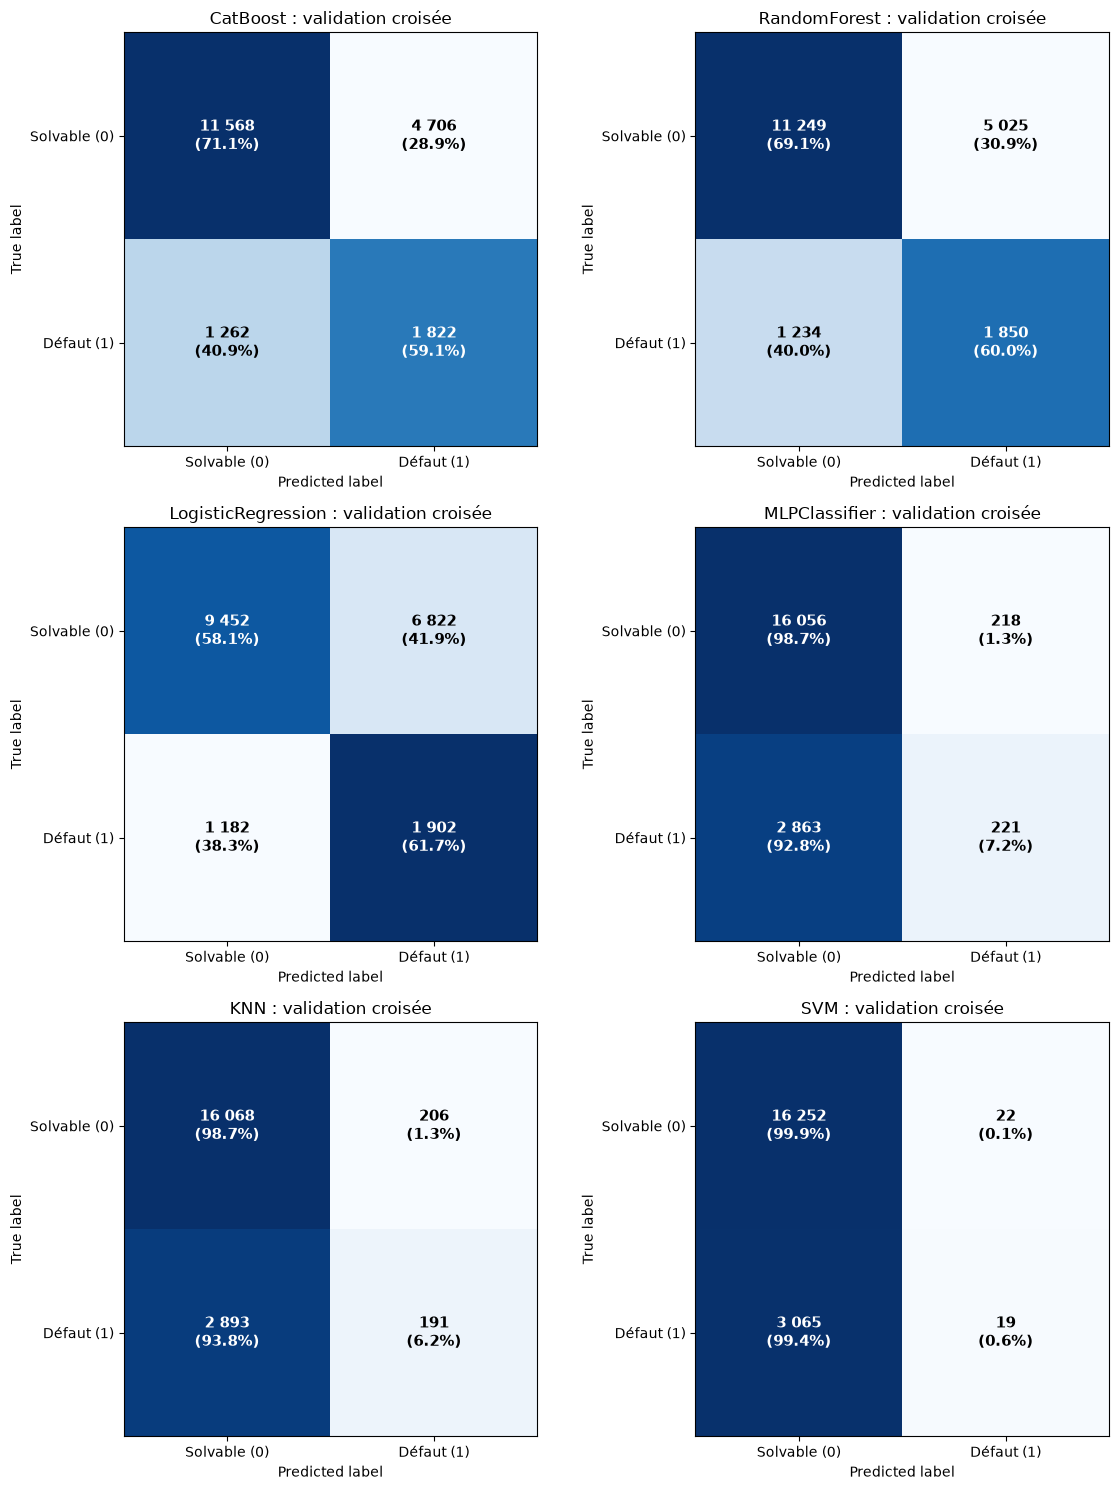

Défauts dans le train : 3084 ; taux de défaut (précision du hasard) : 15.93 %
            Modèle  Prédits en défaut  Défauts détectés  Fausses alertes  Défauts manqués  Précision (%)  Rappel (%)
          CatBoost               6528              1822             4706             1262          27.91       59.08
      RandomForest               6875              1850             5025             1234          26.91       59.99
LogisticRegression               8724              1902             6822             1182          21.80       61.67
     MLPClassifier                439               221              218             2863          50.34        7.17
               KNN                397               191              206             2893          48.11        6.19
               SVM                 41                19               22             3065          46.34        0.62

=== IMPORTANCE DES VARIABLES (%) ===
             CatBoost  RandomForest  LogisticRegression  MLPClass

In [15]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict

ordre = df_final["Modèle"].tolist()
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
lignes = []
for ax, nom in zip(axes.flatten(), ordre):
    pred = cross_val_predict(best_models[nom], X_train, y_train, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_train, pred)
    cm_part = cm / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_part, display_labels=["Solvable (0)", "Défaut (1)"]).plot(cmap="Blues", ax=ax, colorbar=False, include_values=False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cm_part[i, j]:.1%})".replace(",", " "), ha="center", va="center",
                    color="white" if cm_part[i, j] > 0.5 else "black", fontweight="bold", fontsize=11)
    ax.set_title(f"{nom} : validation croisée")
    tn, fp, fn, tp = cm.ravel()
    lignes.append({
        "Modèle": nom, "Prédits en défaut": tp + fp, "Défauts détectés": tp, "Fausses alertes": fp, "Défauts manqués": fn,
        "Précision (%)": tp / (tp + fp) * 100 if tp + fp else np.nan, "Rappel (%)": tp / (tp + fn) * 100,
    })
plt.tight_layout()
plt.show()

df_detection = pd.DataFrame(lignes).round(2)
print(f"Défauts dans le train : {y_train.sum()} ; taux de défaut (précision du hasard) : {y_train.mean() * 100:.2f} %")
print(df_detection.to_string(index=False))

# Importance des variables
noms_variables = [n.split("__", 1)[1] for n in best_models[ordre[0]][0].get_feature_names_out()]
importances = {}
for nom in ordre:
    clf = best_models[nom][-1]
    if isinstance(clf, CalibratedClassifierCV):
        clf = clf.calibrated_classifiers_[0].estimator
    if hasattr(clf, "feature_importances_"):
        brut = np.asarray(clf.feature_importances_, dtype=float)
    elif hasattr(clf, "coef_"):
        brut = np.abs(clf.coef_[0])
    elif hasattr(clf, "coefs_"):
        brut = np.abs(clf.coefs_[0]).sum(axis=1)
    else:
        continue
    importances[nom] = brut / brut.sum() * 100
df_importances = pd.DataFrame(importances, index=noms_variables)
df_importances["Moyenne (%)"] = df_importances.mean(axis=1)
print("\n=== IMPORTANCE DES VARIABLES (%) ===")
print(df_importances.sort_values("Moyenne (%)", ascending=False).round(2).to_string())

**Lecture** : un modèle se juge sur le couple défauts détectés / précision, pas sur l'un des deux seul : détecter plus de défauts coûte en général des fausses alertes. La précision se compare au taux de défaut du train (la précision d'un tirage au hasard). Les importances ne se comparent qu'à l'intérieur d'une colonne : chaque modèle mesure le poids des variables à sa façon.

## 5. Podium et enregistrement

Le podium classe les modèles retenus (après l'ajustement à la main) par score de décision en validation, avec le détail des scores. La colonne « Écart au premier » est comparée à l'écart-type du premier : si l'écart est plus petit, le modèle est **à égalité** avec le premier (la différence est dans le bruit de la validation croisée).
Le premier du podium est enregistré dans `lab_ML/best_models/`.

In [16]:
import joblib

premier = df_final.iloc[0]
podium = df_final[["Modèle", "Score de décision (val)", "Écart-type décision (val)", "F2 (val)", "ROC AUC (val)",
                   "Rappel (val)", "Précision (val)", "Écart train - val", "Alerte"]].copy()
podium["Écart au premier"] = premier["Score de décision (val)"] - podium["Score de décision (val)"]
podium["À égalité avec le premier"] = podium["Écart au premier"] <= premier["Écart-type décision (val)"]
print(podium.round(4).to_string(index=False))
print()
for rang, ligne in podium.head(3).iterrows():
    print(f"{['🥇', '🥈', '🥉'][rang]} {ligne['Modèle']} : score de décision {ligne['Score de décision (val)']:.4f} ± {ligne['Écart-type décision (val)']:.4f}  {ligne['Alerte']}")

# Enregistrement du meilleur modèle (entraîné sur tout le train par la GridSearch)
dossier_modeles = root_dir / "lab_ML" / "best_models"
dossier_modeles.mkdir(exist_ok=True)
chemin = dossier_modeles / f"model_ml_{numero_scenario}.joblib"
joblib.dump(best_models[premier["Modèle"]], chemin)
print(f"\nModèle enregistré : {chemin}")

            Modèle  Score de décision (val)  Écart-type décision (val)  F2 (val)  ROC AUC (val)  Rappel (val)  Précision (val)  Écart train - val                     Alerte  Écart au premier  À égalité avec le premier
          CatBoost                   0.5981                     0.0130    0.4828         0.7135        0.5908           0.2791             0.0679        ⚠️ SURAPPRENTISSAGE            0.0000                       True
      RandomForest                   0.5949                     0.0136    0.4813         0.7085        0.5999           0.2691             0.0374                       ✅ OK            0.0032                       True
LogisticRegression                   0.5492                     0.0072    0.4515         0.6470        0.6167           0.2180             0.0053                       ✅ OK            0.0489                      False
     MLPClassifier                   0.3812                     0.0440    0.0849         0.6774        0.0717           0.4092  

## Conclusion

*À rédiger après l'exécution, à partir des tableaux ci-dessus, puis à reporter dans `lab_ML/tableau_ML.md`.*